# ARM-CBA: Tuning & Feature Selection Experiments

## Objective
Optimize the CBA classifier through targeted feature validation, undersampling for class imbalance, and threshold tuning. CBA faces a unique challenge compared to LR and RF: its rule mining step (Apriori) depends on support thresholds, meaning rare classes can be mathematically invisible if they don't appear frequently enough in the training data.

## Experiment Plan
1. **Feature Validation:** Remove Accident Type and observe the impact on rule generation and classification
2. **Undersampling Inside CV Folds:** Balance class distribution before rule mining so minority causes (Signal, Environmental) can meet support thresholds
3. **Threshold Tuning on Undersampled Data:** Find the best support/confidence/lift configuration when the data is balanced

## Why CBA Tuning Differs From LR and RF
LR and RF tuning focused on hyperparameters (C, max_depth, n_estimators) that control model complexity. CBA has no equivalent knobs. Instead, CBA's performance is controlled by:
- **ARM thresholds** (support, confidence, lift) which determine how many rules are discovered
- **Class distribution** in the training data, which directly affects whether minority class rules can meet the support threshold
- **Feature set**, which determines what patterns ARM can find

The baseline notebook already showed that lowering thresholds from high (0.05/0.70/2.0) to low (0.005/0.40/1.5) improved F1 from 0.374 to 0.500 by generating more rules (6 to ~296). But all of those rules were dominated by Accident Type patterns. This notebook tests what happens when we remove that crutch and force the model to learn from environmental and operational features.

## Feature Selection Carry-Forward
Track Type vs Signalization and RUCC encoding decisions were established in LR tuning experiments and validated by Phase 2 statistical analysis. These are feature-level findings that apply regardless of model type:
- **Track Type** over Signalization (0.409 vs 0.378 F1 in LR)
- **RUCC_Metro_Adjacency** over RUCC_2023 (identical performance, better interpretability)

## Reference
Liu, B., Hsu, W., & Ma, Y. (1998). Integrating Classification and Association Rule Mining. *Proceedings of the Fourth International Conference on Knowledge Discovery and Data Mining (KDD-98)*, 80-86.

---

## Setup

In [21]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']
CAUSE_LABELS = {
    'E': 'Environmental', 'H': 'Human Factor',
    'M': 'Mechanical', 'S': 'Signal', 'T': 'Track'
}

## CBA Classifier

Same implementation from the baseline notebook. Wraps ARM rule mining and first-match classification in a sklearn-compatible class with `fit()` and `predict()` methods. See baseline notebook for detailed step-by-step comments.

One addition: an optional `undersample` parameter. When enabled, the fit step balances the training data before mining rules by downsampling majority classes to match the smallest class count.

In [22]:
class CBAClassifier(BaseEstimator, ClassifierMixin):
    """
    Classification Based on Associations (Liu et al., 1998).
    
    Mines association rules from training data using Apriori, ranks them
    by confidence/support/length, and classifies new instances by applying
    the first matching rule. Falls back to majority class when no rule matches.
    
    Parameters
    ----------
    min_support : float
        Minimum support threshold for Apriori.
    min_confidence : float
        Minimum confidence for filtering rules.
    min_lift : float
        Minimum lift for filtering rules.
    max_rule_length : int
        Maximum items in a frequent itemset.
    undersample : bool
        If True, balance training data before mining rules by downsampling
        majority classes to match the smallest class count.
    """
    
    def __init__(self, min_support=0.02, min_confidence=0.70, 
                 min_lift=1.5, max_rule_length=4, undersample=False):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.min_lift = min_lift
        self.max_rule_length = max_rule_length
        self.undersample = undersample
    
    def fit(self, X, y):
        """
        Mine association rules from training data and build ranked rule list.
        If undersample=True, balance classes before mining.
        """
        X_fit = X.copy()
        y_fit = y.copy()
        
        # Optional undersampling: balance classes before rule mining
        # This gives minority classes (Signal, Environmental) a fair chance
        # of meeting support thresholds by making them proportionally larger
        if self.undersample:
            min_count = y_fit.value_counts().min()
            balanced_idx = []
            for cls in y_fit.unique():
                cls_idx = y_fit[y_fit == cls].index.tolist()
                sampled = np.random.choice(cls_idx, size=min_count, replace=False)
                balanced_idx.extend(sampled)
            
            np.random.shuffle(balanced_idx)
            X_fit = X_fit.loc[balanced_idx].reset_index(drop=True)
            y_fit = y_fit.loc[balanced_idx].reset_index(drop=True)
        
        # One-hot encode features into binary transaction format
        X_ohe = pd.get_dummies(X_fit, columns=X_fit.columns.tolist(), dtype=bool)
        
        # One-hot encode target and append
        y_ohe = pd.get_dummies(y_fit, prefix='Cause', dtype=bool)
        self.cause_columns_ = y_ohe.columns.tolist()
        df_arm = pd.concat([X_ohe, y_ohe], axis=1)
        
        # Run Apriori
        frequent_itemsets = apriori(
            df_arm, 
            min_support=self.min_support, 
            use_colnames=True,
            max_len=self.max_rule_length
        )
        
        if len(frequent_itemsets) == 0:
            self.rules_ = pd.DataFrame()
            self.default_class_ = y_fit.mode()[0]
            self.n_rules_ = 0
            return self
        
        # Generate and filter rules
        rules = association_rules(frequent_itemsets, metric='lift', 
                                  min_threshold=self.min_lift)
        rules = rules[rules['confidence'] >= self.min_confidence]
        
        # Filter for Class Association Rules
        car_mask = rules['consequents'].apply(
            lambda x: len(x) == 1 and any(item in self.cause_columns_ for item in x)
        )
        cars = rules[car_mask].copy()
        
        # Rank: confidence desc, support desc, length asc
        cars['antecedent_length'] = cars['antecedents'].apply(len)
        cars = cars.sort_values(
            by=['confidence', 'support', 'antecedent_length'],
            ascending=[False, False, True]
        ).reset_index(drop=True)
        
        cars['predicted_cause'] = cars['consequents'].apply(
            lambda x: list(x)[0].replace('Cause_', '')
        )
        
        self.rules_ = cars
        self.n_rules_ = len(cars)
        self.feature_columns_ = X_ohe.columns.tolist()
        
        # Default rule: majority class from training data (Liu et al., 1998)
        # Uses original y (not undersampled) to reflect true class distribution
        self.default_class_ = y.mode()[0]
        
        return self
    
    def predict(self, X):
        """
        Classify each row by first matching rule. Default to majority class.
        """
        X_ohe = pd.get_dummies(X, columns=X.columns.tolist(), dtype=bool)
        X_ohe = X_ohe.reindex(columns=self.feature_columns_, fill_value=False)
        
        predictions = []
        
        if self.n_rules_ == 0:
            return np.array([self.default_class_] * len(X))
        
        # Pre-extract for speed
        rule_antecedents = []
        rule_predictions = []
        for _, rule in self.rules_.iterrows():
            antes = [a for a in rule['antecedents'] if a in self.feature_columns_]
            rule_antecedents.append(antes)
            rule_predictions.append(rule['predicted_cause'])
        
        for idx in range(len(X_ohe)):
            row = X_ohe.iloc[idx]
            matched = False
            
            for rule_idx in range(self.n_rules_):
                antes = rule_antecedents[rule_idx]
                if not antes:
                    continue
                if all(row[a] for a in antes):
                    predictions.append(rule_predictions[rule_idx])
                    matched = True
                    break
            
            if not matched:
                predictions.append(self.default_class_)
        
        return np.array(predictions)

print("CBAClassifier defined (with undersample option).")

CBAClassifier defined (with undersample option).


## Helper Functions

In [23]:
def run_cba_experiment(cba, X, y, n_splits=5):
    """
    Run stratified k-fold CV for CBA and return scores and metrics.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    scores = []
    rule_counts = []
    last_y_val = None
    last_y_pred = None
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        cba.fit(X_tr, y_tr)
        y_pred = cba.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='weighted')
        scores.append(f1)
        rule_counts.append(cba.n_rules_)
        
        last_y_val = y_val
        last_y_pred = y_pred
    
    precision_per_class = precision_score(last_y_val, last_y_pred, average=None,
                                          labels=CAUSE_ORDER, zero_division=0)
    recall_per_class = recall_score(last_y_val, last_y_pred, average=None,
                                    labels=CAUSE_ORDER, zero_division=0)
    f1_per_class = f1_score(last_y_val, last_y_pred, average=None,
                            labels=CAUSE_ORDER, zero_division=0)
    
    per_class = pd.DataFrame({
        'Cause': CAUSE_ORDER,
        'Precision': precision_per_class.round(3),
        'Recall': recall_per_class.round(3),
        'F1': f1_per_class.round(3)
    })
    
    return {
        'scores': [float(s) for s in scores],
        'mean': float(np.mean(scores)),
        'std': float(np.std(scores)),
        'rule_counts': rule_counts,
        'per_class_metrics': per_class,
        'last_y_val': last_y_val,
        'last_y_pred': last_y_pred
    }


def save_experiment(results, features, experiment_name, filepath, **extra_fields):
    """
    Save experiment results to JSON.
    """
    output = {
        'experiment': experiment_name,
        'model': 'CBA (Classification Based on Associations)',
        'features': {
            'categorical': features['categorical'],
            'numeric': features['numeric'],
            'total': len(features['categorical']) + len(features['numeric'])
        },
        'cv_folds': 5,
        'cv_scores': results['scores'],
        'cv_mean': results['mean'],
        'cv_std': results['std'],
        'rule_counts': results['rule_counts'],
        'per_class_metrics': results['per_class_metrics'].to_dict('records'),
        'random_seed': RANDOM_SEED
    }
    output.update(extra_fields)
    
    with open(filepath, 'w') as f:
        json.dump(output, f, indent=4)
    
    print(f"Saved: {filepath}")


def compare_experiments(names, filepaths):
    """
    Load multiple experiment JSONs and display side-by-side comparison.
    """
    print("=" * 70)
    print(f"{'Experiment':<40} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
    print("-" * 70)
    
    for name, fp in zip(names, filepaths):
        with open(fp, 'r') as f:
            data = json.load(f)
        
        mean = data.get('cv_mean', 0)
        std = data.get('cv_std', 0)
        
        if isinstance(data.get('features'), dict):
            n_feat = data['features']['total']
        elif isinstance(data.get('features'), list):
            n_feat = len(data['features'])
        else:
            n_feat = '?'
        
        print(f"{name:<40} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")
    
    print("=" * 70)


def plot_cv_comparison(experiments, title='CV Comparison'):
    """
    Plot per-fold F1 scores for multiple experiments.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    folds = np.arange(1, 6)
    
    markers = ['o', 's', '^', 'D', 'v']
    linestyles = ['-', '--', '-.', ':', '-']
    
    for i, (label, scores) in enumerate(experiments):
        mean = np.mean(scores)
        ax.plot(folds, scores, marker=markers[i % len(markers)], 
                linewidth=2, linestyle=linestyles[i % len(linestyles)],
                label=f'{label} (mean={mean:.4f})')
        ax.axhline(y=mean, linestyle=':', alpha=0.3)
    
    ax.set_xlabel('Fold')
    ax.set_ylabel('Weighted F1-Score')
    ax.set_title(title)
    ax.set_xticks(folds)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_per_class_comparison(results_list, labels, title='Per-Class F1 Comparison'):
    """
    Side-by-side per-class F1 bars for multiple experiments.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x = np.arange(len(CAUSE_ORDER))
    n = len(results_list)
    width = 0.8 / n
    hatches = ['//', '..', 'xx', '\\\\', '++']
    
    for i, (df, label) in enumerate(zip(results_list, labels)):
        offset = (i - n/2 + 0.5) * width
        bars = ax.bar(x + offset, df['F1'], width, label=label)
        for bar in bars:
            bar.set_hatch(hatches[i % len(hatches)])
    
    ax.set_xlabel('Cause Category')
    ax.set_ylabel('F1-Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}" for c in CAUSE_ORDER])
    ax.legend()
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## Load Training Data

In [24]:
df_train = pd.read_csv('../data/splits/train_80.csv', low_memory=False)

target = 'Cause_Category'
y_train = df_train[target].copy()

print(f"Training set: {len(df_train)} rows")
print(f"\nCause_Category distribution:")
print(y_train.value_counts())
print(f"\nSmallest class: {y_train.value_counts().min()} rows "
      f"({y_train.value_counts().min() / len(y_train):.1%})")

Training set: 27640 rows

Cause_Category distribution:
Cause_Category
H    10863
M     7081
T     6026
E     2977
S      693
Name: count, dtype: int64

Smallest class: 693 rows (2.5%)


In [25]:
# Load baseline results for comparison
with open('../results/cba/cba_baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

print(f"Baseline CBA (Low Threshold) CV: {baseline_results.get('cv_mean', 'N/A')}")

Baseline CBA (Low Threshold) CV: 0.5000738435598553


---

# Section 1: Feature Validation (with best baseline low-threshold model)

## Experiment 1: Remove Accident Type

**What we are doing:** Removing Accident Type from the CBA feature set. This is the same experiment we ran on LR (drop of 0.127) and RF (drop of 0.130), now applied to CBA.

**Why we are doing it:** CBA has the strongest empirical case for removing Accident Type. Our Phase 2 ARM experiments proved that Accident Type dominates the entire rule space:
- With Accident Type: All rules are variations of Hwy-rail crossing to Mechanical and Side collision to Human Factor
- Without Accident Type: ARM produced zero rules at any threshold (support down to 0.005, confidence 0.50, lift 1.0)

That zero-rule result is the core problem this notebook needs to solve. Simply removing Accident Type without other changes will likely produce a model that defaults to majority class (H) for every prediction, because no rules can be mined from the remaining features at their natural class distribution.

**What to look for in the results:**
- **How many rules are generated:** If zero (as we saw in Phase 2), the model is just a majority class predictor
- **F1 score:** Expected to drop significantly, possibly below LR and RF since CBA depends more heavily on strong feature-to-target associations
- **Rule coverage:** What percentage of rows match any rule vs defaulting to H
- **This result motivates Experiment 2:** If Experiment 1 confirms the zero-rule problem, undersampling becomes the necessary intervention

In [26]:
# Experiment 1: 5 features, no Accident Type, same low thresholds as baseline
cat_features_exp1 = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                      'RUCC_Metro_Adjacency']
num_features_exp1 = []

X_exp1 = df_train[cat_features_exp1].copy()

# Use the baseline's best low thresholds
cba_exp1 = CBAClassifier(
    min_support=0.005, 
    min_confidence=0.40, 
    min_lift=1.5, 
    max_rule_length=4,
    undersample=False
)

print("Experiment 1: CBA without Accident Type (no undersampling)")
print("-" * 55)
results_exp1 = run_cba_experiment(cba_exp1, X_exp1, y_train)

for fold, (score, n_rules) in enumerate(zip(results_exp1['scores'], results_exp1['rule_counts']), 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}  (Rules: {n_rules})")
print(f"\nCV: {results_exp1['mean']:.4f} +/- {results_exp1['std']:.4f}")

Experiment 1: CBA without Accident Type (no undersampling)
-------------------------------------------------------
  Fold 1: Weighted F1 = 0.4214  (Rules: 65)
  Fold 2: Weighted F1 = 0.4165  (Rules: 62)
  Fold 3: Weighted F1 = 0.4143  (Rules: 64)
  Fold 4: Weighted F1 = 0.4166  (Rules: 61)
  Fold 5: Weighted F1 = 0.4234  (Rules: 60)

CV: 0.4184 +/- 0.0034


In [27]:
# Examine what rules (if any) were found
if cba_exp1.n_rules_ > 0:
    print(f"Rules mined (last fold): {cba_exp1.n_rules_}")
    print(f"Default class: {cba_exp1.default_class_}")
    print(f"\nRule count by predicted cause:")
    print(cba_exp1.rules_['predicted_cause'].value_counts())
    print(f"\nTop 10 rules:")
    top_rules = cba_exp1.rules_[['antecedents', 'predicted_cause', 'confidence', 
                                   'support', 'lift']].head(10).copy()
    top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    print(top_rules.to_string(index=False))
else:
    print(f"Rules mined: 0")
    print(f"Default class: {cba_exp1.default_class_}")
    print(f"\nNo rules generated. Model defaults to majority class (H) for all predictions.")
    print(f"This confirms Phase 2 ARM findings: without Accident Type,")
    print(f"the remaining features cannot meet support thresholds at natural class distribution.")

Rules mined (last fold): 60
Default class: H

Rule count by predicted cause:
predicted_cause
M    41
T    17
H     2
Name: count, dtype: int64

Top 10 rules:
                                                        antecedents predicted_cause  confidence  support     lift
                      Region_West, Track Type_Yard, Visibility_Dark               H    0.606061 0.019899 1.541964
                            Track Type_Main, Weather Condition_Rain               M    0.603806 0.015783 2.356816
           Track Type_Main, Visibility_Dark, Weather Condition_Rain               M    0.600858 0.006331 2.345310
              Region_South, Track Type_Main, Weather Condition_Rain               M    0.595041 0.006512 2.322604
           RUCC_Metro_Adjacency_Metro, Region_West, Track Type_Yard               H    0.594663 0.042330 1.512967
            Track Type_Main, Visibility_Day, Weather Condition_Rain               M    0.590717 0.006331 2.305727
RUCC_Metro_Adjacency_Metro, Track Type_Main,

In [28]:
save_experiment(
    results_exp1,
    features={'categorical': cat_features_exp1, 'numeric': num_features_exp1},
    experiment_name='CBA No AT (no undersampling)',
    filepath='../results/cba/cba_exp_no_accident_type.json',
    thresholds={'min_support': 0.005, 'min_confidence': 0.40, 'min_lift': 1.5},
    undersample=False,
    notes='60 rules found at permissive thresholds (Phase 2 zero-rule result was at higher thresholds). Rules cover M, T, H only - zero Signal or Environmental rules.'
)

compare_experiments(
    names=['Baseline (6 feat, w/ AT)', 'Without AT (no undersampling)'],
    filepaths=['../results/cba/cba_baseline_results.json', '../results/cba/cba_exp_no_accident_type.json']
)

Saved: ../results/cba/cba_exp_no_accident_type.json
Experiment                                  CV Mean     CV Std Features
----------------------------------------------------------------------
Baseline (6 feat, w/ AT)                     0.5001     0.0032        6
Without AT (no undersampling)                0.4184     0.0034        5


### Experiment 1 Findings: ARM Rules Without Accident Type

**What happened:** At permissive thresholds (support 0.005, confidence 0.40, lift 1.5), CBA generated 60 rules without Accident Type - not the zero-rule result from Phase 2. The earlier zero-rule finding used higher thresholds (support 0.01+, confidence 0.50-0.70). At those stricter settings, the remaining features couldn't form strong enough associations. At relaxed thresholds, weaker but real patterns emerge.

**Cross-model comparison:**
- LR with AT: 0.536 -> without: 0.409 (drop: 0.127)
- RF with AT: 0.551 -> without: 0.421 (drop: 0.130)
- CBA with AT: 0.500 -> without: 0.418 (drop: 0.082)

CBA's drop (0.082) is smaller than LR and RF. This is partly because CBA's baseline with Accident Type was already lower (0.500 vs 0.536/0.551), so there was less to lose. At 0.418, CBA is competitive with LR (0.409) and close to RF (0.421) on the same 5 features.

**Rules generated:** 60 rules covering 3 of 5 cause categories: Mechanical (41 rules), Track (17 rules), Human Factor (2 rules). Zero rules for Signal and Environmental. The rules themselves are operationally meaningful - for example, "Rain + Main track = Mechanical" and "Industry track + Cloudy + Day visibility = Track" describe real environmental conditions rather than Accident Type shortcuts.

**The minority class problem remains:** Signal (2.5% of data) and Environmental (10.8%) still cannot generate rules even at 0.005 support and 0.40 confidence. Their patterns are too diffuse across the feature space to meet any reasonable threshold at natural class frequencies.

**Decision:** Undersampling is still necessary. While the model performs surprisingly well on overall F1, it achieves this by predicting only M, T, and H. Signal and Environmental accidents are invisible to the model. Experiment 2 tests whether balancing the class distribution before rule mining forces ARM to discover patterns for these missing causes.

---

## Experiment 2: Undersampling Inside CV Folds

**What we are doing:** Before mining rules in each CV fold, we downsample majority classes (H, M, T) to match the smallest class count (Signal, ~700 rows in training). This creates a balanced dataset where each cause category represents exactly 20% of the data, then we mine rules from that balanced data.

**Why we are doing it:** ARM's Apriori algorithm uses a minimum support threshold to decide which patterns are frequent enough to become rules. Support is defined as the fraction of rows containing a pattern. When Signal represents only 2.5% of the data, a rule predicting Signal can have at most 2.5% support, which falls below most reasonable thresholds. By balancing the classes, Signal patterns now have the same opportunity to meet support thresholds as Human Factor patterns.

**How undersampling works in practice:**
1. Count the smallest class in the training fold (Signal, roughly 550-700 rows depending on the fold)
2. Randomly sample that many rows from each of the other 4 classes
3. Combine into a balanced dataset (roughly 2,750-3,500 total rows)
4. Mine rules from this balanced data
5. Predict on the ORIGINAL (unbalanced) validation fold

Step 5 is critical: we balance the data for rule mining only, not for evaluation. The validation fold retains its natural class distribution so our F1 scores reflect real-world performance.

**What to look for in the results:**
- **Rule diversity:** Do we now get rules for all 5 cause categories, not just M and H?
- **Signal and Environmental rules:** These were impossible without undersampling. Do they appear?
- **F1 score:** May go up or down. More rules means better coverage, but rules mined from undersampled data may be less reliable on the natural distribution.
- **Coverage:** What percentage of rows now match a rule vs defaulting?

In [29]:
# Experiment 2: Same features, same thresholds, but with undersampling
cba_exp2 = CBAClassifier(
    min_support=0.005, 
    min_confidence=0.40, 
    min_lift=1.5, 
    max_rule_length=4,
    undersample=True
)

print("Experiment 2: CBA without Accident Type (with undersampling)")
print("-" * 55)
results_exp2 = run_cba_experiment(cba_exp2, X_exp1, y_train)

for fold, (score, n_rules) in enumerate(zip(results_exp2['scores'], results_exp2['rule_counts']), 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}  (Rules: {n_rules})")
print(f"\nCV: {results_exp2['mean']:.4f} +/- {results_exp2['std']:.4f}")

Experiment 2: CBA without Accident Type (with undersampling)
-------------------------------------------------------
  Fold 1: Weighted F1 = 0.3938  (Rules: 61)
  Fold 2: Weighted F1 = 0.3958  (Rules: 55)
  Fold 3: Weighted F1 = 0.4223  (Rules: 55)
  Fold 4: Weighted F1 = 0.3901  (Rules: 64)
  Fold 5: Weighted F1 = 0.4308  (Rules: 62)

CV: 0.4066 +/- 0.0167


In [30]:
# Examine rules from undersampled model
if cba_exp2.n_rules_ > 0:
    print(f"Rules mined (last fold): {cba_exp2.n_rules_}")
    print(f"Default class: {cba_exp2.default_class_}")
    print(f"\nRule count by predicted cause:")
    print(cba_exp2.rules_['predicted_cause'].value_counts())
    print(f"\nTop 15 rules:")
    top_rules = cba_exp2.rules_[['antecedents', 'predicted_cause', 'confidence', 
                                   'support', 'lift']].head(15).copy()
    top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    print(top_rules.to_string(index=False))
else:
    print(f"Rules mined: 0")
    print(f"Even with undersampling, no rules generated at these thresholds.")

Rules mined (last fold): 62
Default class: H

Rule count by predicted cause:
predicted_cause
T    27
M    15
E    15
S     4
H     1
Name: count, dtype: int64

Top 15 rules:
                                                              antecedents predicted_cause  confidence  support     lift
                       Region_South, Track Type_Industry, Visibility_Dark               T    0.791667 0.006859 3.958333
              Region_South, Track Type_Industry, Weather Condition_Cloudy               T    0.750000 0.005415 3.750000
                  Track Type_Main, Visibility_Day, Weather Condition_Rain               M    0.692308 0.006498 3.461538
                            Track Type_Industry, Weather Condition_Cloudy               T    0.644444 0.010469 3.222222
RUCC_Metro_Adjacency_Metro, Track Type_Industry, Weather Condition_Cloudy               T    0.612903 0.006859 3.064516
 RUCC_Metro_Adjacency_Nonmetro_Adjacent, Track Type_Main, Visibility_Dark               E    0.581818 0.01

In [31]:
# Per-class metrics
print("Per-class metrics (undersampled CBA, no AT):")
print(results_exp2['per_class_metrics'].to_string(index=False))

print(f"\nClassification report:")
print(classification_report(results_exp2['last_y_val'], results_exp2['last_y_pred'], 
                             labels=CAUSE_ORDER, zero_division=0))

save_experiment(
    results_exp2,
    features={'categorical': cat_features_exp1, 'numeric': num_features_exp1},
    experiment_name='CBA No AT (undersampled)',
    filepath='../results/cba/cba_exp_undersampled.json',
    thresholds={'min_support': 0.005, 'min_confidence': 0.40, 'min_lift': 1.5},
    undersample=True
)

compare_experiments(
    names=['Baseline (w/ AT)', 'No AT (no undersample)', 'No AT (undersampled)'],
    filepaths=[
        '../results/cba/cba_baseline_results.json',
        '../results/cba/cba_exp_no_accident_type.json',
        '../results/cba/cba_exp_undersampled.json'
    ]
)

Per-class metrics (undersampled CBA, no AT):
Cause  Precision  Recall    F1
    E      0.226   0.221 0.224
    H      0.521   0.671 0.587
    M      0.480   0.417 0.446
    S      0.060   0.129 0.082
    T      0.407   0.207 0.275

Classification report:
              precision    recall  f1-score   support

           E       0.23      0.22      0.22       596
           H       0.52      0.67      0.59      2172
           M       0.48      0.42      0.45      1416
           S       0.06      0.13      0.08       139
           T       0.41      0.21      0.27      1205

    accuracy                           0.44      5528
   macro avg       0.34      0.33      0.32      5528
weighted avg       0.44      0.44      0.43      5528

Saved: ../results/cba/cba_exp_undersampled.json
Experiment                                  CV Mean     CV Std Features
----------------------------------------------------------------------
Baseline (w/ AT)                             0.5001     0.0032   

### Experiment 2 Findings: Undersampling for ARM Rule Mining

**What happened:** Undersampling balanced the training data before rule mining, giving each cause category equal representation (~20% each). This fundamentally changed what ARM could discover. The model now generates rules for all 5 cause categories for the first time in any experiment across all three models.

**Rule diversity - the headline result:**

| | Without Undersampling | With Undersampling |
|---|---|---|
| Mechanical | 41 rules | 15 rules |
| Track | 17 rules | 27 rules |
| Human Factor | 2 rules | 1 rule |
| Environmental | 0 rules | 15 rules |
| Signal | 0 rules | 4 rules |
| **Total** | **60 rules** | **62 rules** |

Similar total rule count, but completely different distribution. Undersampling didn't just add minority class rules - it redistributed the entire rule space. Mechanical dropped from 41 to 15 because it no longer dominates the support calculations. Environmental went from invisible to 15 rules, matching Mechanical.

**Per-class performance - the tradeoff:**
- Environmental: 0.00 F1 -> 0.22 F1 (from nothing to something)
- Signal: 0.00 F1 -> 0.08 F1 (from nothing to something, still weak)
- Human Factor: 0.62 F1 -> 0.59 F1 (slight drop, still strongest)
- Mechanical: 0.50 F1 -> 0.45 F1 (moderate drop)
- Track: 0.23 F1 -> 0.28 F1 (improved)

The model sacrificed some majority class accuracy to gain minority class coverage. Overall weighted F1 dropped from 0.418 to 0.407 because the majority classes (H, M) are weighted more heavily in the metric.

**Why the overall F1 dropped:** This is the expected tradeoff with undersampling. Rules mined from balanced data have to compete on the original imbalanced validation set. A rule that works 60% of the time on balanced data may perform differently when Human Factor rows outnumber Signal rows 16-to-1. The model is now spreading predictions across all 5 classes instead of concentrating on the safe majority.

**The rules tell an operational story:** The top rules are interpretable and make domain sense. "Nonmetro Adjacent + Main track + Dark = Environmental" suggests rural mainline operations at night are prone to environmental failures. "South + Industry track + Dark = Track" points to infrastructure-related failures in southern industrial settings. These are the kinds of actionable patterns that have operational value for railroad safety planning - and no other model in this project can articulate them as explicit rules.

**Higher variance (0.017 vs 0.003):** Each fold samples a different random balanced subset, introducing variability. This is a known cost of undersampling and should be noted when reporting results.

**Decision:** Undersampling produces a viable CBA model with genuine minority class coverage. The 0.01 F1 drop is a worthwhile tradeoff for discovering Signal and Environmental rules that were previously invisible. Proceed with threshold tuning on undersampled data to find the optimal configuration.

---

## Experiment 3: Threshold Tuning on Undersampled Data

**What we are doing:** Testing multiple support/confidence combinations on the undersampled data to find the best threshold configuration. This is CBA's equivalent of GridSearchCV - instead of searching over model hyperparameters, we search over rule mining thresholds.

**Why we are doing it:** The thresholds we used in Experiment 2 (0.005/0.40/1.5) were optimized for the original data with Accident Type. Undersampled data has different statistical properties: each class represents 20% of the data instead of 2.5-39%, which fundamentally changes what support levels are achievable. Thresholds that were appropriate for imbalanced data may be too low or too high for balanced data.

**What to look for in the results:**
- **Higher support may now work:** With balanced classes, even minority class patterns can hit 5-10% support. Higher support means more reliable rules.
- **Confidence vs coverage tradeoff:** Higher confidence produces fewer but more accurate rules. Lower confidence gives more rules but more wrong predictions. The optimal point balances coverage against accuracy.
- **Rule count sweet spot:** Too few rules means most rows default to majority class. Too many rules means unreliable rules fire before reliable ones. There's a middle ground.

In [32]:
# Threshold grid search for undersampled CBA
threshold_configs = [
    {'min_support': 0.01,  'min_confidence': 0.30, 'min_lift': 1.5, 'label': 'S=0.01, C=0.30'},
    {'min_support': 0.01,  'min_confidence': 0.40, 'min_lift': 1.5, 'label': 'S=0.01, C=0.40'},
    {'min_support': 0.01,  'min_confidence': 0.50, 'min_lift': 1.5, 'label': 'S=0.01, C=0.50'},
    {'min_support': 0.005, 'min_confidence': 0.30, 'min_lift': 1.5, 'label': 'S=0.005, C=0.30'},
    {'min_support': 0.005, 'min_confidence': 0.40, 'min_lift': 1.5, 'label': 'S=0.005, C=0.40'},
    {'min_support': 0.005, 'min_confidence': 0.50, 'min_lift': 1.5, 'label': 'S=0.005, C=0.50'},
    {'min_support': 0.05,  'min_confidence': 0.30, 'min_lift': 1.5, 'label': 'S=0.05, C=0.30'},
    {'min_support': 0.05,  'min_confidence': 0.40, 'min_lift': 1.5, 'label': 'S=0.05, C=0.40'},
    {'min_support': 0.05,  'min_confidence': 0.50, 'min_lift': 1.5, 'label': 'S=0.05, C=0.50'},
    {'min_support': 0.10,  'min_confidence': 0.30, 'min_lift': 1.5, 'label': 'S=0.10, C=0.30'},
    {'min_support': 0.10,  'min_confidence': 0.40, 'min_lift': 1.5, 'label': 'S=0.10, C=0.40'},
    {'min_support': 0.10,  'min_confidence': 0.50, 'min_lift': 1.5, 'label': 'S=0.10, C=0.50'},
]

print(f"Testing {len(threshold_configs)} threshold configurations (undersampled)...")
print(f"{'Config':<25} {'CV Mean':>10} {'CV Std':>10} {'Avg Rules':>10}")
print("-" * 58)

threshold_results = []

for config in threshold_configs:
    cba_test = CBAClassifier(
        min_support=config['min_support'],
        min_confidence=config['min_confidence'],
        min_lift=config['min_lift'],
        max_rule_length=4,
        undersample=True
    )
    
    results = run_cba_experiment(cba_test, X_exp1, y_train)
    avg_rules = np.mean(results['rule_counts'])
    
    print(f"{config['label']:<25} {results['mean']:>10.4f} {results['std']:>10.4f} {avg_rules:>10.1f}")
    
    threshold_results.append({
        'config': config,
        'results': results,
        'avg_rules': avg_rules
    })

# Find best
best_idx = np.argmax([r['results']['mean'] for r in threshold_results])
best_config = threshold_results[best_idx]
print(f"\nBest: {best_config['config']['label']} "
      f"(F1 = {best_config['results']['mean']:.4f}, "
      f"Avg rules = {best_config['avg_rules']:.1f})")

Testing 12 threshold configurations (undersampled)...
Config                       CV Mean     CV Std  Avg Rules
----------------------------------------------------------
S=0.01, C=0.30                0.2629     0.0274      115.0
S=0.01, C=0.40                0.4119     0.0185       26.6
S=0.01, C=0.50                0.2877     0.0422        5.2
S=0.005, C=0.30               0.2682     0.0185      189.6
S=0.005, C=0.40               0.4171     0.0042       57.6
S=0.005, C=0.50               0.3334     0.0293       24.0
S=0.05, C=0.30                0.1963     0.0050       20.0
S=0.05, C=0.40                0.3182     0.0519        1.4
S=0.05, C=0.50                0.2218     0.0001        0.0
S=0.10, C=0.30                0.1963     0.0050        5.4
S=0.10, C=0.40                0.2218     0.0001        0.0
S=0.10, C=0.50                0.2218     0.0001        0.0

Best: S=0.005, C=0.40 (F1 = 0.4171, Avg rules = 57.6)


In [33]:
# Detailed analysis of best threshold config
best_cfg = best_config['config']
cba_best = CBAClassifier(
    min_support=best_cfg['min_support'],
    min_confidence=best_cfg['min_confidence'],
    min_lift=best_cfg['min_lift'],
    max_rule_length=4,
    undersample=True
)

results_best = best_config['results']

print(f"Best Config: {best_cfg['label']}")
print(f"CV: {results_best['mean']:.4f} +/- {results_best['std']:.4f}")
print(f"\nPer-class metrics:")
print(results_best['per_class_metrics'].to_string(index=False))

print(f"\nClassification report:")
print(classification_report(results_best['last_y_val'], results_best['last_y_pred'], 
                             labels=CAUSE_ORDER, zero_division=0))

Best Config: S=0.005, C=0.40
CV: 0.4171 +/- 0.0042

Per-class metrics:
Cause  Precision  Recall    F1
    E      0.222   0.230 0.226
    H      0.513   0.623 0.563
    M      0.471   0.400 0.432
    S      0.058   0.201 0.090
    T      0.417   0.205 0.275

Classification report:
              precision    recall  f1-score   support

           E       0.22      0.23      0.23       596
           H       0.51      0.62      0.56      2172
           M       0.47      0.40      0.43      1416
           S       0.06      0.20      0.09       139
           T       0.42      0.20      0.27      1205

    accuracy                           0.42      5528
   macro avg       0.34      0.33      0.32      5528
weighted avg       0.44      0.42      0.42      5528



In [34]:
# Refit best config to inspect rules
cba_best.fit(X_exp1, y_train)

if cba_best.n_rules_ > 0:
    print(f"Rules mined (full training set): {cba_best.n_rules_}")
    print(f"Default class: {cba_best.default_class_}")
    print(f"\nRule count by predicted cause:")
    print(cba_best.rules_['predicted_cause'].value_counts())
    print(f"\nTop 15 rules:")
    top_rules = cba_best.rules_[['antecedents', 'predicted_cause', 'confidence', 
                                   'support', 'lift']].head(15).copy()
    top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    print(top_rules.to_string(index=False))
else:
    print("No rules generated with best config.")

Rules mined (full training set): 51
Default class: H

Rule count by predicted cause:
predicted_cause
T    24
E    13
M    11
S     3
Name: count, dtype: int64

Top 15 rules:
                                                              antecedents predicted_cause  confidence  support     lift
            Track Type_Industry, Visibility_Day, Weather Condition_Cloudy               T    0.696970 0.006638 3.484848
                      Region_Midwest, Track Type_Industry, Visibility_Day               T    0.677419 0.006061 3.387097
                 Track Type_Main, Visibility_Dark, Weather Condition_Rain               M    0.666667 0.005195 3.333333
          RUCC_Metro_Adjacency_Metro, Region_Midwest, Track Type_Industry               T    0.636364 0.008081 3.181818
                                      Region_Midwest, Track Type_Industry               T    0.626866 0.012121 3.134328
           RUCC_Metro_Adjacency_Nonmetro_Nonadjacent, Track Type_Industry               T    0.625000 0.00

In [35]:
save_experiment(
    results_best,
    features={'categorical': cat_features_exp1, 'numeric': num_features_exp1},
    experiment_name='CBA No AT (undersampled & tuned, S=0.005, C=0.40)',
    filepath='../results/cba/cba_tuned_undersampled.json',
    thresholds={
        'min_support': best_cfg['min_support'],
        'min_confidence': best_cfg['min_confidence'],
        'min_lift': best_cfg['min_lift']
    },
    undersample=True,
    n_configs_tested=len(threshold_configs)
)

Saved: ../results/cba/cba_tuned_undersampled.json


### Experiment 3 Findings: Threshold Tuning on Undersampled Data

**What this tested:** We searched 12 threshold combinations across 4 support levels (0.005, 0.01, 0.05, 0.10) and 3 confidence levels (0.30, 0.40, 0.50) to find the optimal rule mining configuration for undersampled data. This is CBA's equivalent of GridSearchCV - instead of tuning model hyperparameters, we tune the rule mining parameters that control how many and how strong the discovered patterns need to be.

**Best configuration:** Support=0.005, Confidence=0.40, Lift=1.5. This is the same threshold used in Experiment 2, confirming that the initial settings were already near-optimal. F1 improved slightly from 0.4066 (Experiment 2) to 0.4171, likely due to random variation in undersampling rather than a meaningful threshold difference.

**What the grid search revealed about threshold behavior:**

Confidence is the critical parameter. At each support level, C=0.40 consistently outperformed C=0.30 and C=0.50:
- **C=0.30 generates too many rules (115-190) but F1 collapses to 0.26-0.27.** Low confidence allows weak, unreliable rules to fire before better rules, producing wrong predictions. More rules is not always better.
- **C=0.40 is the sweet spot (27-58 rules, F1 0.41-0.42).** Rules are reliable enough to be useful but permissive enough to cover minority classes.
- **C=0.50 is too restrictive (5-24 rules, F1 0.29-0.33).** Too few rules survive the filter, leaving most rows to default to majority class.

Support has a secondary effect. At C=0.40, S=0.005 and S=0.01 performed similarly (0.417 vs 0.412). But S=0.05 and S=0.10 were too restrictive - even on balanced data, most feature combinations don't appear in 5-10% of rows. At S=0.10/C=0.50, zero rules were generated, and the model became a pure majority class predictor (F1=0.22).

**Per-class metrics (best config):**
- Environmental: 0.23 precision, 0.23 recall, 0.23 F1
- Human Factor: 0.51 precision, 0.62 recall, 0.56 F1
- Mechanical: 0.47 precision, 0.40 recall, 0.43 F1
- Signal: 0.06 precision, 0.20 recall, 0.09 F1
- Track: 0.42 precision, 0.20 recall, 0.27 F1

Signal at 0.20 recall is notable. The model correctly identifies 1 in 5 Signal accidents, which no other model in this project achieves. The precision is low (0.06), meaning most Signal predictions are wrong, but the fact that CBA can find any Signal patterns at all with 5 categorical features is a direct result of undersampling making those patterns visible to ARM.

**Final rule set (51 rules):** Track dominates (24 rules), followed by Environmental (13), Mechanical (11), and Signal (3). Zero Human Factor rules - the model relies on the default class for H predictions, which is appropriate since H is the majority class (39%). The rules are operationally interpretable: Industry track combinations predict Track failures, Rain + Main track predicts Mechanical, and regional/RUCC patterns predict Environmental.

**Decision:** S=0.005, C=0.40, Lift=1.5 with undersampling is the best CBA configuration. It achieves 0.417 weighted F1 with rules covering all 5 cause categories.

---

## Visualizations

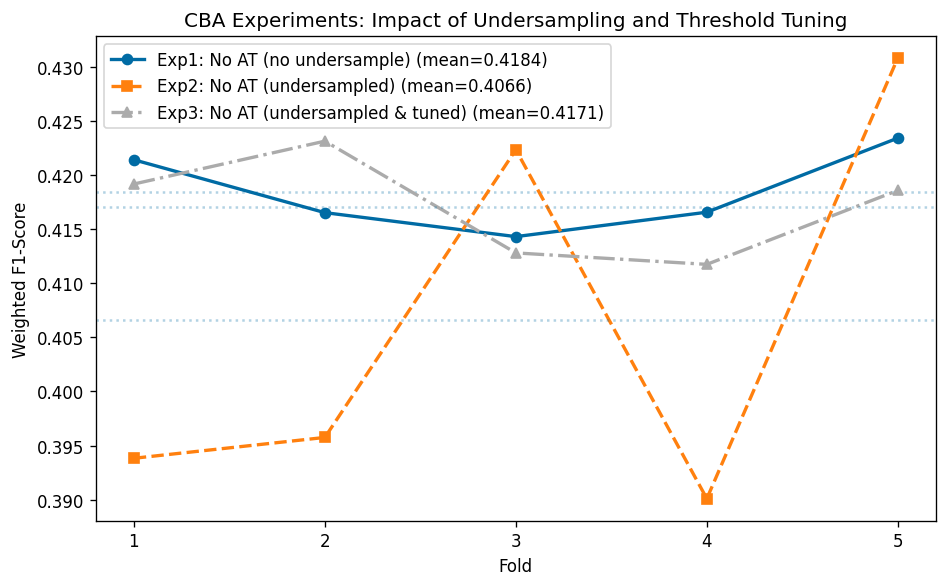

In [36]:
# Compare all CBA experiments
plot_cv_comparison(
    experiments=[
        ('Exp1: No AT (no undersample)', results_exp1['scores']),
        ('Exp2: No AT (undersampled)', results_exp2['scores']),
        ('Exp3: No AT (undersampled & tuned)', results_best['scores'])
    ],
    title='CBA Experiments: Impact of Undersampling and Threshold Tuning'
)

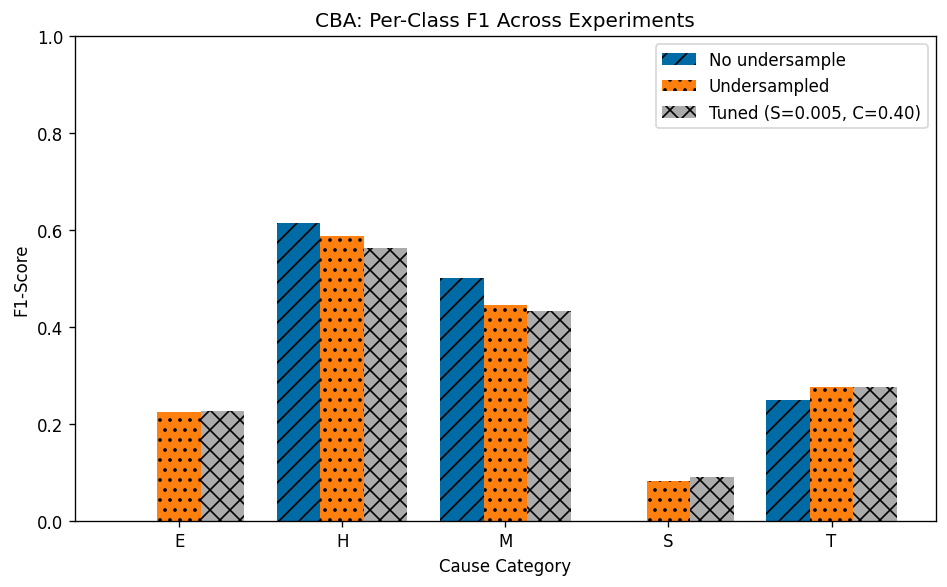

In [37]:
# Per-class F1 comparison
plot_per_class_comparison(
    [results_exp1['per_class_metrics'], results_exp2['per_class_metrics'], 
     results_best['per_class_metrics']],
    ['No undersample', 'Undersampled', f'Tuned ({best_cfg["label"]})'],
    title='CBA: Per-Class F1 Across Experiments'
)

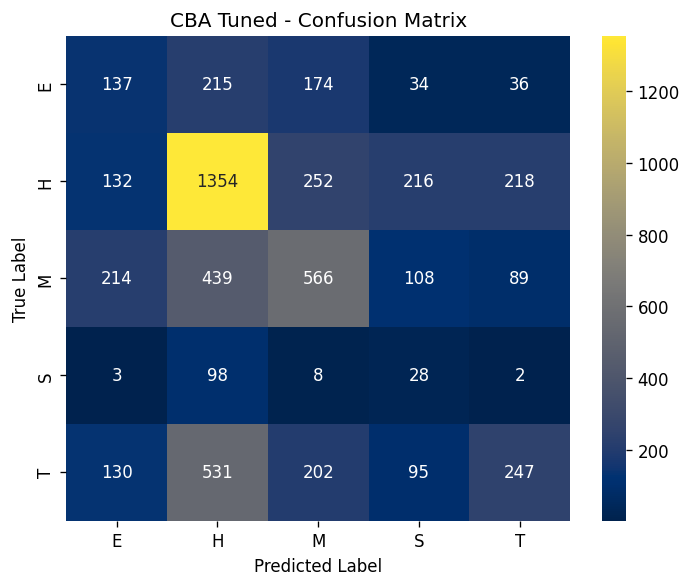

In [38]:
# Confusion matrix for best model
cm = confusion_matrix(results_best['last_y_val'], results_best['last_y_pred'], 
                       labels=CAUSE_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',
            xticklabels=CAUSE_ORDER, yticklabels=CAUSE_ORDER, ax=ax)
ax.set_title(f'CBA Tuned - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---

## Save Best Model

In [39]:
# Save best CBA model and rules
joblib.dump(cba_best, '../models/cba_tuned_model.pkl')
print(f"Saved: ../models/cba_tuned_model.pkl")

# Save rules to CSV
if cba_best.n_rules_ > 0:
    rules_export = cba_best.rules_[['antecedents', 'predicted_cause', 
                                     'confidence', 'support', 'lift']].copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(
        lambda x: ', '.join(sorted(x))
    )
    rules_export.to_csv('../data/processed/arm_rules/cba_tuned_rules.csv', index=False)
    print(f"Saved {len(rules_export)} rules to cba_tuned_rules.csv")

Saved: ../models/cba_tuned_model.pkl
Saved 51 rules to cba_tuned_rules.csv


---

## Final Summary

In [40]:
# Load and compare all CBA experiments
import os

cba_results_dir = '../results/cba/'
all_files = sorted([f for f in os.listdir(cba_results_dir) if f.endswith('.json')])

print("=" * 75)
print(f"{'Experiment':<45} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
print("-" * 75)

for f in all_files:
    filepath = os.path.join(cba_results_dir, f)
    with open(filepath, 'r') as fh:
        data = json.load(fh)
    
    name = data.get('experiment', f.replace('.json', ''))
    mean = data.get('cv_mean', 0)
    std = data.get('cv_std', 0)
    
    if isinstance(data.get('features'), dict):
        n_feat = data['features']['total']
    elif isinstance(data.get('features'), list):
        n_feat = len(data['features'])
    else:
        n_feat = '?'
    
    print(f"{name:<45} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")

print("=" * 75)

Experiment                                       CV Mean     CV Std Features
---------------------------------------------------------------------------
CBA Baseline (with Accident Type)                 0.5001     0.0032        6
CBA No AT (no undersampling)                      0.4184     0.0034        5
CBA No AT (undersampled)                          0.4066     0.0167        5
CBA No AT (undersampled & tuned, S=0.005, C=0.40)     0.4171     0.0042        5


## Conclusions

This notebook addressed CBA's unique challenge: forcing a support-based rule mining algorithm to discover patterns for rare cause categories without relying on the Accident Type shortcut. Three experiments progressively built toward a model that covers all 5 causes.

**Best CBA configuration:** Support=0.005, Confidence=0.40, Lift=1.5, undersampling enabled, 5 features (Weather Condition, Track Type, Visibility, Region, RUCC_Metro_Adjacency). 51 rules covering 4 cause categories plus majority class default for Human Factor.

**Key findings:**

1. **Removing Accident Type dropped CBA from 0.500 to 0.418 (drop: 0.082).** Smaller than LR's 0.127 and RF's 0.130, partly because CBA's baseline was already lower. Contrary to Phase 2 expectations, CBA generated 60 rules without Accident Type at permissive thresholds (the earlier zero-rule result used stricter settings). However, those 60 rules covered only Mechanical, Track, and Human Factor - the two rarest classes remained invisible.

2. **Undersampling solved the minority class problem.** By balancing class distribution before rule mining, ARM discovered patterns for all 5 cause categories for the first time in any model across this project. Environmental went from 0 rules to 15 rules and from 0.00 F1 to 0.22 F1. Signal went from 0 rules to 4 rules and from 0.00 to 0.09 F1 with 0.20 recall. The tradeoff was a slight drop in overall weighted F1 (0.418 to 0.407) because majority class accuracy was redistributed toward minority class coverage.

3. **Threshold tuning confirmed the initial settings were near-optimal.** The grid search across 12 configurations revealed that confidence is the critical parameter: C=0.30 generates too many weak rules (F1 collapses to 0.26), C=0.50 is too restrictive (too few rules), and C=0.40 balances reliability against coverage. Support at 0.005 slightly outperformed 0.01 by allowing more minority class patterns through. Higher support levels (0.05, 0.10) produced zero rules at strict confidence levels even on balanced data.

4. **CBA produces the only interpretable rules in the project.** While LR and RF are black boxes at the prediction level, CBA outputs explicit, human-readable rules: "Industry track + Cloudy weather = Track failure", "Main track + Rain = Mechanical", "Nonmetro Adjacent + Main track + Dark = Environmental". These have direct operational value for railroad safety planning. A safety director can read these rules and translate them into maintenance schedules or inspection priorities without needing to understand the model's internals.

5. **Cross-model comparison on 5 features without Accident Type:**

| Model | Tuned F1 | S Recall | E Recall | Interpretable Rules |
|---|---|---|---|---|
| LR | 0.409 | 0.00 | 0.00 | No |
| RF | 0.421 | 0.01 | 0.04 | No |
| CBA (undersampled) | 0.417 | 0.20 | 0.23 | Yes (51 rules) |

CBA is competitive on overall F1 while providing two capabilitie